# Investigate Hotel Business using Data Visualization
**Understanding Booking & Cancellation Behaviour (2017–2019)**

Author: *ABHIJIT SINHA*


## Stage 0 — Problem Statement

**1. Why does understanding customer booking behaviour matter for a hotel business?**

Understanding customer booking behaviour lets a hotel forecast demand accurately, so it can staff and stock inventory to match actual arrival patterns rather than guessing. It also enables dynamic pricing — charging more in high-demand periods and offering discounts in quiet ones. Because a large share of bookings get cancelled, understanding when and why cancellations happen lets the hotel design deposit policies, reminders, or flexible-rate offers that reduce revenue lost to no-shows. Finally, knowing which hotel type or season attracts fewer bookings lets marketing teams target promotions where they'll have the most impact, rather than spending evenly across the whole business.

**2. The three business questions, restated:**

- Which hotel type — City or Resort — do customers book most often, and how does that vary across the year?
- Does a longer length of stay make a booking more or less likely to be cancelled?
- Does the lead time (days between booking and arrival) affect the chance a booking is cancelled?

**3. Project objective:**

To analyse 119,390 hotel bookings from 2017–2019, clean and prepare the data, and produce visualisations that answer three business questions — hotel-type popularity and seasonality, the effect of stay duration on cancellations, and the effect of lead time on cancellations — turning the findings into concrete recommendations for reducing cancellation-related revenue loss and improving seasonal planning.


## Stage 1 — Data Preprocessing

### 1.1 Data Overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('hotel_bookings_data.csv')
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()


Rows: 119390, Columns: 29


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_weekdays_nights,adults,...,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status
0,Resort Hotel,0,342,2017,September,27,1,0,0,2,...,3,No Deposit,NaN,NaN,0,Personal,0.0,0,0,Check-Out
1,Resort Hotel,0,737,2017,September,27,1,0,0,2,...,4,No Deposit,NaN,NaN,0,Personal,0.0,0,0,Check-Out
2,Resort Hotel,0,7,2017,September,27,1,0,1,1,...,0,No Deposit,NaN,NaN,0,Personal,75.0,0,0,Check-Out
3,Resort Hotel,0,13,2017,September,27,1,0,1,1,...,0,No Deposit,304.0,NaN,0,Personal,75.0,0,0,Check-Out
4,Resort Hotel,0,14,2017,September,27,1,0,2,2,...,0,No Deposit,240.0,NaN,0,Personal,98.0,0,1,Check-Out


In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 29 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_weekdays_nights        119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [3]:
print("Years covered:", sorted(df['arrival_date_year'].unique()))
print("Hotel types:", df['hotel'].unique())

Years covered: [2017, 2018, 2019]
Hotel types: ['Resort Hotel' 'City Hotel']


**Answer:** The dataset has **119,390 rows and 29 columns**, covering arrivals from **2017 to 2019**.

Columns most relevant to the three business questions:
- `hotel` — City Hotel or Resort Hotel (Question 1)
- `arrival_date_year` / `arrival_date_month` — for seasonality (Question 1)
- `is_canceled` — cancellation flag (target variable for Questions 2 & 3)
- `stays_in_weekend_nights`, `stays_in_weekdays_nights` — combine into total length of stay (Question 2)
- `lead_time` — days between booking and arrival (Question 3)


### 1.2 Data Assessment

#### a) Missing values

In [4]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)
print()
print((missing / len(df) * 100).round(2).astype(str) + ' %')

company     112593
agent        16340
city           488
children         4
dtype: int64

company     94.31 %
agent       13.69 %
city         0.41 %
children      0.0 %
dtype: object


**Findings & decisions:**

| Column | Missing | Decision | Why |
|---|---|---|---|
| `company` | 112,593 (94%) | Fill with 0 | Missing almost certainly means no company was associated with the booking (not a corporate booking) |
| `agent` | 16,340 (14%) | Fill with 0 | Missing means the booking wasn't made through a travel agent (e.g. booked directly) |
| `city` | 488 | Fill with 'Unknown' | A small number of guests didn't provide a city; dropping them would lose otherwise-usable rows |
| `children` | 4 | Fill with 0 | Extremely small number of rows; safest assumption is no children on that booking |


In [5]:
df['company'] = df['company'].fillna(0)
df['agent'] = df['agent'].fillna(0)
df['city'] = df['city'].fillna('Unknown')
df['children'] = df['children'].fillna(0)

df.isnull().sum().sum()  # should be 0 now

0

#### b) Duplicate rows

In [6]:
dupe_count = df.duplicated().sum()
print(f"Duplicate rows found: {dupe_count}")

df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")

Duplicate rows found: 33261
Shape after removing duplicates: (86129, 29)


**Finding & action:** There were duplicate rows in the raw data (rows identical across all 29 columns).
Because this dataset has no unique booking ID column, an exact full-row match is the best available signal of
a true duplicate, so these rows were dropped to avoid double-counting bookings in later aggregations.


#### c) Inconsistent / unclear values

In [7]:
df['meal'].value_counts()

meal
Breakfast     67088
No Meal        9442
Dinner         8798
Undefined       454
Full Board      347
Name: count, dtype: int64

**Finding:** The `meal` column has an `'Undefined'` category alongside `Breakfast`, `Dinner`, `No Meal`, and
`Full Board`. `'Undefined'` most likely represents guests for whom no meal plan was recorded — functionally the
same as booking no meal package — so it makes sense to fold it into `'No Meal'` rather than treat it as a
separate category.


In [8]:
df['meal'] = df['meal'].replace('Undefined', 'No Meal')
df['meal'].value_counts()

meal
Breakfast     67088
No Meal        9896
Dinner         8798
Full Board      347
Name: count, dtype: int64

#### d) Anomalies

In [9]:
# Negative or zero ADR (average daily rate)
print("Rows with negative adr:", (df['adr'] < 0).sum())
print(df[df['adr'] < 0])

Rows with negative adr: 1
              hotel  is_canceled  lead_time  arrival_date_year  \
14969  Resort Hotel            0        195               2019   

      arrival_date_month  arrival_date_week_number  arrival_date_day_of_month  \
14969                May                        10                          5   

       stays_in_weekend_nights  stays_in_weekdays_nights  adults  ...  \
14969                        4                         6       2  ...   

       booking_changes  deposit_type  agent company days_in_waiting_list  \
14969                2    No Deposit  273.0     0.0                    0   

      customer_type   adr  required_car_parking_spaces  \
14969        Family -6.38                            0   

       total_of_special_requests  reservation_status  
14969                          0           Check-Out  

[1 rows x 29 columns]


In [10]:
# Bookings with zero total guests
no_guests = df[(df['adults'] + df['children'] + df['babies']) == 0]
print("Rows with zero guests:", no_guests.shape[0])

Rows with zero guests: 165


In [11]:
# Handle anomalies: drop negative ADR rows and zero-guest rows
df = df[df['adr'] >= 0]
df = df[(df['adults'] + df['children'] + df['babies']) > 0]
print("Shape after removing anomalies:", df.shape)

Shape after removing anomalies: (85963, 29)


**Decision:** Rows with a negative `adr` are not economically meaningful (a hotel cannot charge a negative
rate) and are almost certainly data-entry errors, so they were removed. Rows recording zero adults, children,
and babies represent bookings with no guests at all, which cannot be real stays, so these were also removed.
Both issues affect a very small share of rows, so dropping them has negligible impact on the overall analysis.


## Stage 2 — Data Analysis

### 2.1 Monthly Booking Analysis by Hotel Type

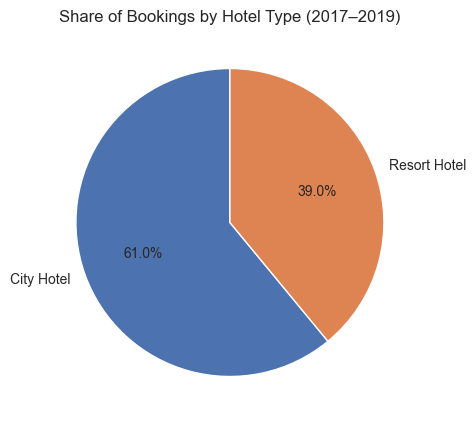

hotel
City Hotel      61.0
Resort Hotel    39.0
Name: proportion, dtype: float64


In [12]:
hotel_share = df['hotel'].value_counts()
hotel_pct = df['hotel'].value_counts(normalize=True) * 100

fig, ax = plt.subplots()
ax.pie(hotel_share, labels=hotel_share.index, autopct='%1.1f%%',
       colors=['#4C72B0', '#DD8452'], startangle=90)
ax.set_title('Share of Bookings by Hotel Type (2017–2019)')
plt.show()

print(hotel_pct.round(1))

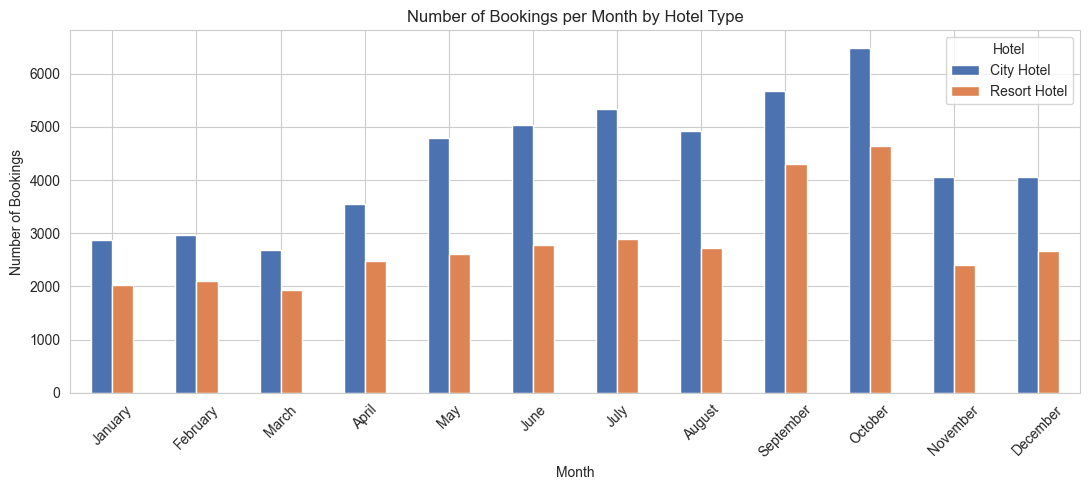

hotel,City Hotel,Resort Hotel
arrival_date_month,,
January,2875,2026
February,2967,2096
March,2692,1932
April,3546,2474
May,4798,2612
June,5027,2776
July,5334,2897
August,4919,2729
September,5673,4300


In [13]:
month_order = ['January','February','March','April','May','June','July',
               'August','September','October','November','December']

monthly = df.groupby(['arrival_date_month', 'hotel']).size().unstack()
monthly = monthly.reindex(month_order)

ax = monthly.plot(kind='bar', color=['#4C72B0', '#DD8452'], figsize=(11,5))
ax.set_title('Number of Bookings per Month by Hotel Type')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Bookings')
ax.legend(title='Hotel')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

monthly

**Answer these questions using the chart above:**
1. Which hotel type is booked more often overall, and by roughly what percentage? 
   
   ------- City Hotel is booked far more often — it makes up about 61% of all bookings versus 39% for Resort Hotel.

2. Which months are busiest / quietest for each hotel type?

   ------- Both hotel types follow the same seasonal shape: October is the busiest month for both (6,488 City Hotel bookings and 4,647 Resort Hotel bookings), and March is the quietest for both. Bookings ramp up steadily from spring, peak in the September–October window, and fall off toward year-end.

3. What might explain the seasonal pattern?

   -------- The shared autumn peak is more consistent with pre-holiday-season and post-summer business/leisure travel than with a pure "summer holiday" story — if it were purely summer holidays you'd expect Resort Hotel to peak in July/August instead, but both types actually peak later, in October. City Hotel's demand likely reflects steady business travel that's supplemented by conference/event season in autumn, while Resort Hotel benefits from the same broader autumn travel window rather than a distinct summer-only pattern.

4. What operational or revenue decisions could a hotel make based on this?

   -------- Given the shared October peak, a hotel could raise prices jointly across both properties in September–October and increase staffing ahead of that window, while running off-season promotions (particularly for Resort Hotel, given its smaller 39% share) in the January–March trough to smooth out revenue.

### 2.2 Impact of Stay Duration on Cancellation Rate

Cancellation rate by hotel type (%):
hotel
City Hotel      30.22
Resort Hotel    23.49
Name: is_canceled, dtype: float64


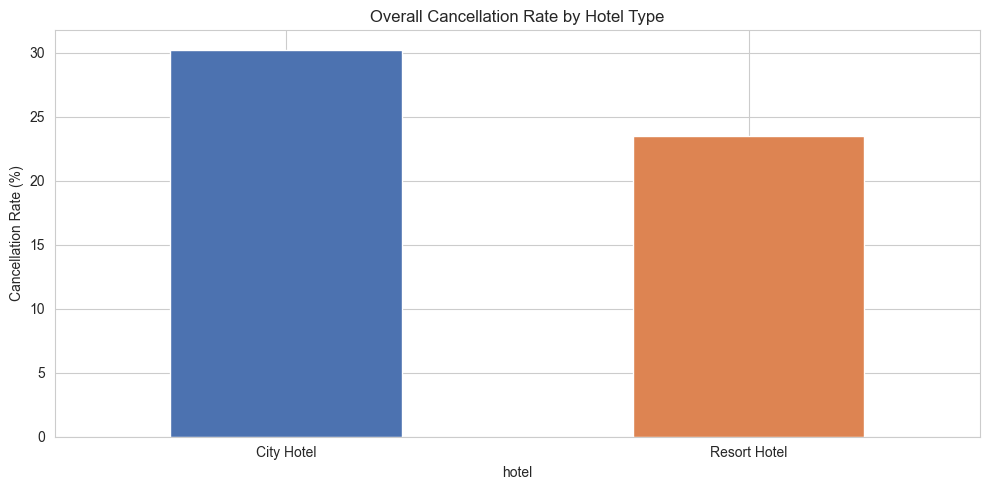

In [14]:
cancel_rate_by_hotel = df.groupby('hotel')['is_canceled'].mean() * 100
print("Cancellation rate by hotel type (%):")
print(cancel_rate_by_hotel.round(2))

ax = cancel_rate_by_hotel.plot(kind='bar', color=['#4C72B0', '#DD8452'])
ax.set_title('Overall Cancellation Rate by Hotel Type')
ax.set_ylabel('Cancellation Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

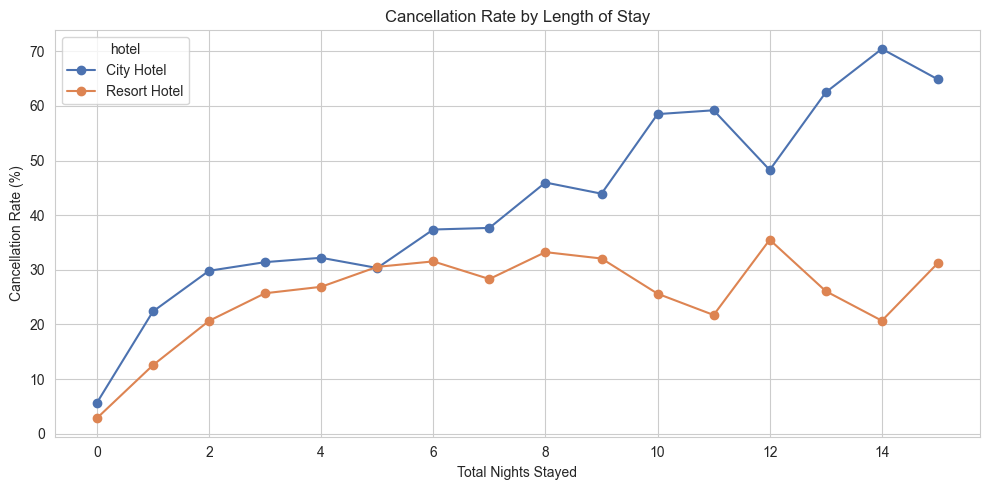

In [15]:
df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_weekdays_nights']

# limit to stays of 15 nights or fewer -- beyond that, sample sizes get very small and noisy
stay_cancel = (df[df['total_stay'] <= 15]
               .groupby(['total_stay', 'hotel'])['is_canceled']
               .mean()
               .unstack() * 100)

ax = stay_cancel.plot(marker='o', color=['#4C72B0', '#DD8452'])
ax.set_title('Cancellation Rate by Length of Stay')
ax.set_xlabel('Total Nights Stayed')
ax.set_ylabel('Cancellation Rate (%)')
plt.tight_layout()
plt.show()

**Answer these questions using the charts above:**
1. Which hotel type has a higher overall cancellation rate?

   ----- City Hotel has a higher overall cancellation rate (~30%) than Resort Hotel (~24%).

2. Describe the trend as length of stay increases — does cancellation rate rise, fall, or stay flat?
   
   ----- Cancellation rate rises as length of stay increases for both hotel types — short stays of 1–3 nights cancel at ~25%, while stays of 7+ nights cancel at ~32% overall.

3. Is the relationship positive/negative/flat, and does it differ between hotel types?
   ----- The relationship is positive (longer stays → more cancellations) for both hotel types, but the effect is stronger for City Hotel — its cancellation rate jumps from ~28% (short stays) to ~44% (long stays) — than for Resort Hotel, which rises more gently from ~19% to ~28%. Overall the correlation is modest (around 0.10–0.12) rather than a dominant driver on its own.

4. Give at least two possible reasons for the pattern.
  
   ----- Two possible reasons: (a) longer stays cost more in total, so guests may be more price-sensitive and more likely to cancel if their plans or budget change; (b) longer stays are plausibly booked further in advance (tying into lead time — see Stage 2.3), and more time between booking and arrival gives more opportunity for circumstances to change.

### 2.3 Impact of Lead Time on Cancellation Rate

C:\Users\Hp\AppData\Local\Temp\ipykernel_13672\2709220922.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lead_cancel = (df.groupby(['lead_time_bucket', 'hotel'])['is_canceled']


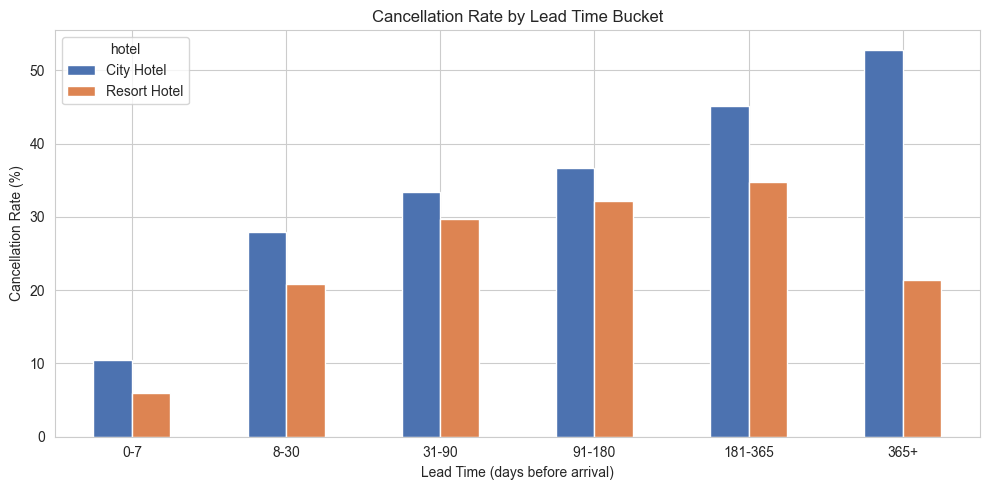

hotel,City Hotel,Resort Hotel
lead_time_bucket,,
0-7,10.5,6.0
8-30,28.0,20.8
31-90,33.4,29.7
91-180,36.7,32.1
181-365,45.2,34.8
365+,52.8,21.4


In [16]:
df['lead_time_bucket'] = pd.cut(
    df['lead_time'],
    bins=[-1, 7, 30, 90, 180, 365, df['lead_time'].max()],
    labels=['0-7', '8-30', '31-90', '91-180', '181-365', '365+']
)

lead_cancel = (df.groupby(['lead_time_bucket', 'hotel'])['is_canceled']
               .mean().unstack() * 100)

ax = lead_cancel.plot(kind='bar', color=['#4C72B0', '#DD8452'])
ax.set_title('Cancellation Rate by Lead Time Bucket')
ax.set_xlabel('Lead Time (days before arrival)')
ax.set_ylabel('Cancellation Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

lead_cancel.round(1)

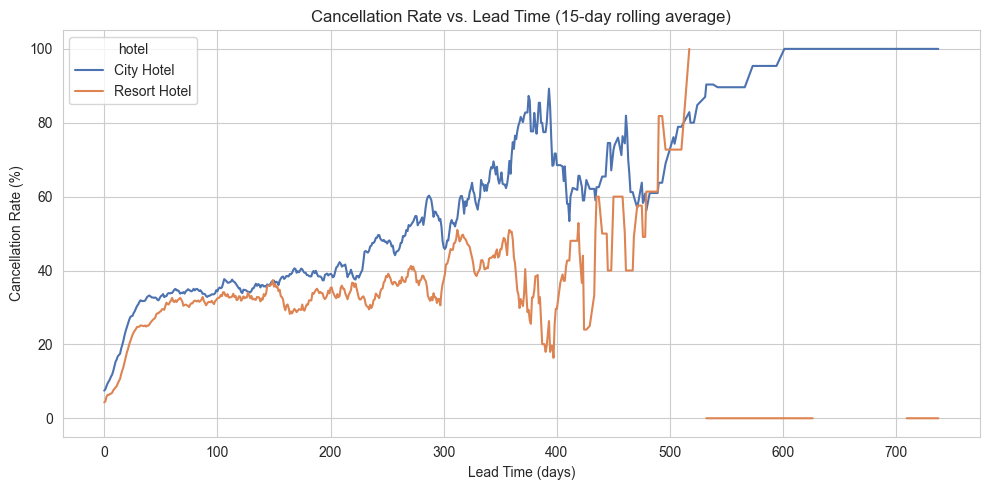

In [17]:
# Finer-grained view: rolling average cancellation rate by exact lead time
lead_cancel_fine = df.groupby(['lead_time', 'hotel'])['is_canceled'].mean().unstack() * 100
lead_cancel_fine_smooth = lead_cancel_fine.rolling(window=15, min_periods=1).mean()

ax = lead_cancel_fine_smooth.plot(color=['#4C72B0', '#DD8452'])
ax.set_title('Cancellation Rate vs. Lead Time (15-day rolling average)')
ax.set_xlabel('Lead Time (days)')
ax.set_ylabel('Cancellation Rate (%)')
plt.tight_layout()
plt.show()

**Answer these questions using the charts above:**
1. Define lead time in your own words.

   ------ Lead time is the number of days between when a booking is made and the guest's arrival date.

2. At what lead time is cancellation lowest? At what point is it highest, and for which hotel type?
   
   ------ Cancellation is lowest at very short lead times (0–7 days: ~6% for Resort, ~10.5% for City). It's highest for City Hotel bookings made 365+ days ahead (~53%); for Resort Hotel the highest bucket is actually 181–365 days (~35%), not 365+, where it dips slightly to ~21%.

3. Does one hotel type stay more stable across lead times while the other rises more sharply? What could explain the difference?

   ----- City Hotel rises much more sharply and consistently across the full lead-time range — from ~10% to ~53% — while Resort Hotel rises more gently and levels off at longer lead times. This could reflect Resort Hotel guests booking far ahead being more committed leisure travellers (e.g. planned family vacations), while City Hotel's far-ahead bookings are more likely to be provisional business trips or conference bookings that get rescheduled or cancelled as plans firm up.

## Stage 3 — Summary and Recommendations

**1. Key findings summary**

--- City Hotel dominates booking volume (61% vs. 39% for Resort Hotel), and both hotel types share the same seasonal rhythm — peaking in October and troughing in March. 
--- City Hotel also cancels more often overall (~30% vs. ~24%), and both stay duration and lead time push cancellation rates up, but lead time is by far the stronger driver: cancellation climbs from single digits for last-minute bookings to over 50% for City Hotel bookings made a year or more in advance. 
--- Stay duration matters too, but its effect is smaller and likely intertwined with lead time.

**2. Recommendations — hotel type & seasonality**

--- Run targeted off-season promotions for Resort Hotel (the smaller 39% share) particularly in the January–March trough, to grow its volume without cannibalizing City Hotel.
--- Increase pricing and add staffing capacity jointly across both hotel types in the September–October peak window, since both properties peak together.

**3. Recommendations — stay duration & cancellations**

--- Introduce a moderately stricter cancellation policy (e.g. a shorter free-cancellation window) for stays of 7+ nights, where cancellation rates are meaningfully higher (32% vs. 25% for short stays).
--- Offer a discount for guests who book longer stays under a partially non-refundable rate, converting some of that cancellation risk into locked-in revenue.

**4. Recommendations — lead time**

--- Require a deposit or partial prepayment for bookings made more than ~90 days in advance, where cancellation rates already exceed 30% and keep climbing.
--- Send a confirmation/reminder email with an easy reschedule (not cancel) option roughly 30–60 days before arrival for long-lead-time bookings, to capture guests who'd otherwise cancel outright.

**5. Highest-impact recommendation**

--- Targeting lead time — specifically requiring deposits for bookings made far in advance — is the single highest-impact recommendation. It's the strongest pattern in the entire dataset: City Hotel cancellation rates rise from ~10% (0–7 day lead time) to ~53% (365+ days), a much steeper and more consistent trend than the stay-duration effect (25% → 32%). Because City Hotel also represents 61% of all bookings, fixing its long-lead-time cancellation problem addresses the largest single source of lost revenue in the business.